# Profiling plots

## Load the data

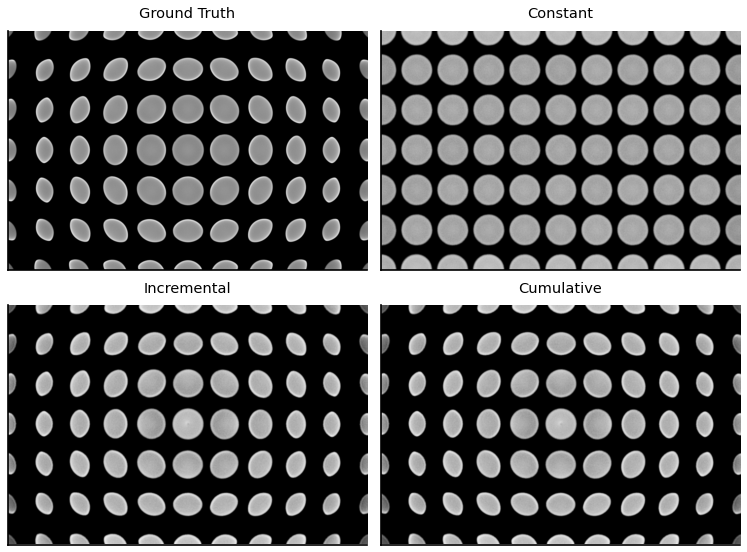

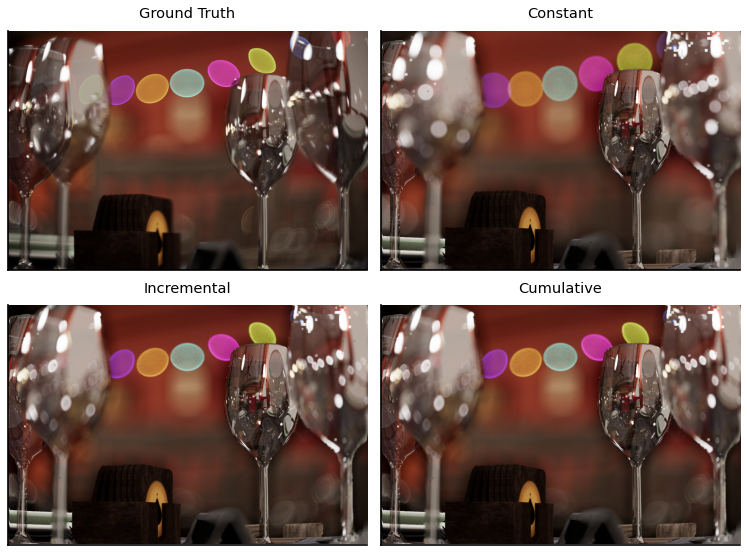

Data loaded from: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314
Output: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314\analysis_output
Bokeh images: (800, 1200, 3), range [0.000, 0.910]
Scene images: (800, 1200, 3)
Tap count variations: 7 per mode


In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import json
from skimage.metrics import structural_similarity as ssim

# Thesis-quality plot settings
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Nimbus Sans', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'legend.framealpha': 0.9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Consistent color scheme and labels
COLORS = {'constant': '#4878CF', 'incremental': '#E67C3A', 'cumulative': '#6BAA6E'}
MARKERS = {'constant': 'D', 'incremental': 'o', 'cumulative': 's'}
METHODS = ['constant', 'incremental', 'cumulative']
METHOD_LABELS = ['Constant', 'Incremental', 'Cumulative']

# 2x2 grid layout: GT + 3 methods
GRID_METHODS = ['ground_truth', 'constant', 'incremental', 'cumulative']
GRID_LABELS = ['Ground Truth', 'Constant', 'Incremental', 'Cumulative']
GRID_POSITIONS = [(0, 0), (0, 1), (1, 0), (1, 1)]

# Figure width for thesis (single-column)
FIG_WIDTH = 6.3

def fig_height_for_grid(img_shape, nrows, ncols, fig_width=FIG_WIDTH, title_inches=0.3):
    """Compute figure height so images display at native aspect ratio."""
    h, w = img_shape[:2]
    cell_width = fig_width / ncols
    cell_height = cell_width * (h / w)
    return nrows * cell_height + title_inches

# Configuration
DATA_ROOT = Path(r"C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314")
OUTPUT_DIR = DATA_ROOT / "analysis_output"
OUTPUT_DIR.mkdir(exist_ok=True)

BOKEH_CONFIG_DIR = DATA_ROOT / "bokeh_config"
SCENE_DIR = DATA_ROOT / "scene"

# Helper functions
def load_image(path):
    """Load image as numpy array normalized to [0, 1] range (RGB only)."""
    img = Image.open(path)
    if img.mode == 'RGBA':
        img = img.convert('RGB')
    elif img.mode != 'RGB':
        img = img.convert('RGB')
    img_arr = np.array(img)
    if img_arr.dtype == np.uint8:
        return img_arr.astype(np.float32) / 255.0
    elif img_arr.dtype == np.uint16:
        return img_arr.astype(np.float32) / 65535.0
    else:
        return img_arr.astype(np.float32)

def load_json(path):
    """Load JSON file."""
    with open(path, 'r') as f:
        return json.load(f)

# Load bokeh_config images
bokeh_images = {
    'ground_truth': load_image(BOKEH_CONFIG_DIR / "ground_truth" / "realistic_lens_ground_truth.png"),
    'constant': load_image(BOKEH_CONFIG_DIR / "images" / "gather_dof_spatially_constant.png"),
    'incremental': load_image(BOKEH_CONFIG_DIR / "images" / "gather_dof_spatially_varying_incremental.png"),
    'cumulative': load_image(BOKEH_CONFIG_DIR / "images" / "gather_dof_spatially_varying_cumulative.png"),
}

# Load scene images
scene_images = {
    'ground_truth': load_image(SCENE_DIR / "ground_truth" / "lens_simulation_ground_truth.png"),
    'constant': load_image(SCENE_DIR / "images" / "gather_dof_spatially_constant.png"),
    'incremental': load_image(SCENE_DIR / "images" / "gather_dof_spatially_varying_incremental.png"),
    'cumulative': load_image(SCENE_DIR / "images" / "gather_dof_spatially_varying_cumulative.png"),
}

# Load profiling JSON data for bokeh_config
bokeh_profiling = {
    'constant': load_json(BOKEH_CONFIG_DIR / "profiling" / "gather_dof_spatially_constant_detail.json"),
    'incremental': load_json(BOKEH_CONFIG_DIR / "profiling" / "gather_dof_spatially_varying_incremental_detail.json"),
    'cumulative': load_json(BOKEH_CONFIG_DIR / "profiling" / "gather_dof_spatially_varying_cumulative_detail.json"),
}

# Load profiling JSON data for scene
scene_profiling = {
    'constant': load_json(SCENE_DIR / "profiling" / "gather_dof_spatially_constant_detail.json"),
    'incremental': load_json(SCENE_DIR / "profiling" / "gather_dof_spatially_varying_incremental_detail.json"),
    'cumulative': load_json(SCENE_DIR / "profiling" / "gather_dof_spatially_varying_cumulative_detail.json"),
}

# Load tap count comparison data for bokeh_config
tap_counts = [1, 5, 10, 20, 40, 60, 80]
tap_count_data = {'constant': {}, 'incremental': {}, 'cumulative': {}}

for mode in METHODS:
    for tc in tap_counts:
        tap_dir = BOKEH_CONFIG_DIR / "tap_count_comparison" / mode
        tap_count_data[mode][tc] = {
            'image': load_image(tap_dir / f"gather_dof_tap_count_{tc:02d}.png"),
            'profiling': load_json(tap_dir / f"tap_count_{tc:02d}_detail.json"),
        }

# Preview: 2x2 per category (GT+Constant / Incremental+Cumulative)
for cat_key, images, cat_label in [('bokeh_config', bokeh_images, 'Bokeh Config'),
                                    ('scene', scene_images, 'Scene')]:
    ref_img = images['ground_truth']
    fh = fig_height_for_grid(ref_img.shape, 2, 2)
    fig, axes = plt.subplots(2, 2, figsize=(FIG_WIDTH, fh),
                             gridspec_kw={'wspace': 0.04, 'hspace': 0.12})
    for (r, c), method, label in zip(GRID_POSITIONS, GRID_METHODS, GRID_LABELS):
        axes[r, c].imshow(images[method])
        axes[r, c].set_title(label)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    #fig.suptitle(cat_label, fontsize=10, y=0.99)
    plt.savefig(OUTPUT_DIR / f"loaded_images_preview_{cat_key}.svg", format='svg', bbox_inches='tight')
    plt.show()

print(f"Data loaded from: {DATA_ROOT}")
print(f"Output: {OUTPUT_DIR}")
print(f"Bokeh images: {bokeh_images['ground_truth'].shape}, range [{bokeh_images['ground_truth'].min():.3f}, {bokeh_images['ground_truth'].max():.3f}]")
print(f"Scene images: {scene_images['ground_truth'].shape}")
print(f"Tap count variations: {len(tap_counts)} per mode")


## Quality

BOKEH CONFIG - Quality Metrics
Constant        - L1: 0.168962, PSNR: 10.35 dB, SSIM: 0.5569
Incremental     - L1: 0.045340, PSNR: 20.52 dB, SSIM: 0.8792
Cumulative      - L1: 0.045399, PSNR: 20.52 dB, SSIM: 0.8790

SCENE - Quality Metrics
Constant        - L1: 0.093643, PSNR: 15.80 dB, SSIM: 0.6346
Incremental     - L1: 0.084389, PSNR: 16.21 dB, SSIM: 0.6393
Cumulative      - L1: 0.084395, PSNR: 16.21 dB, SSIM: 0.6392


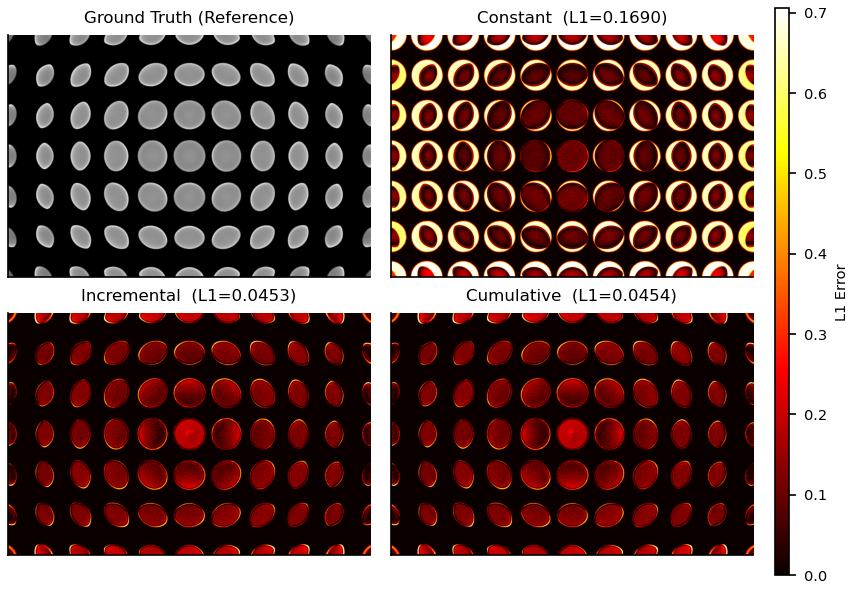

Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314\analysis_output\quality_l1_difference_maps_bokeh.svg


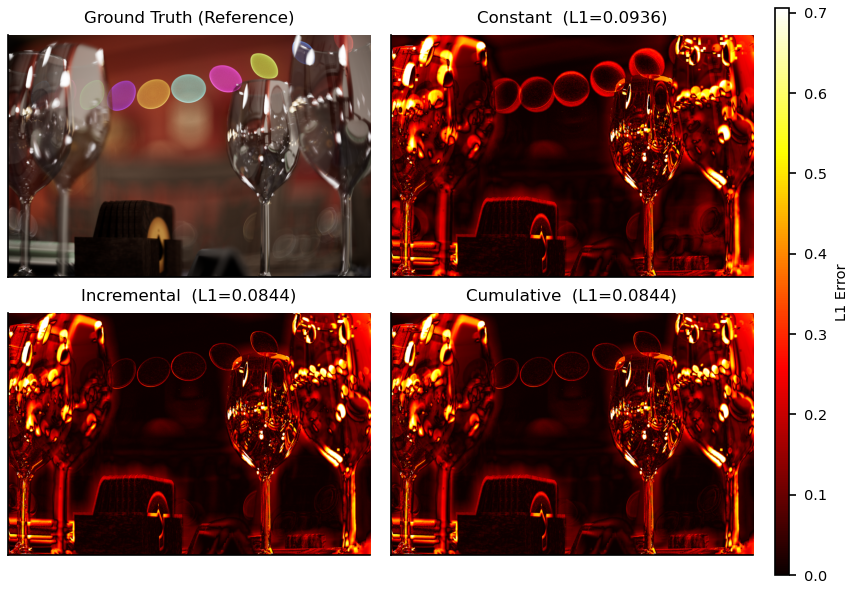

Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314\analysis_output\quality_l1_difference_maps_scene.svg


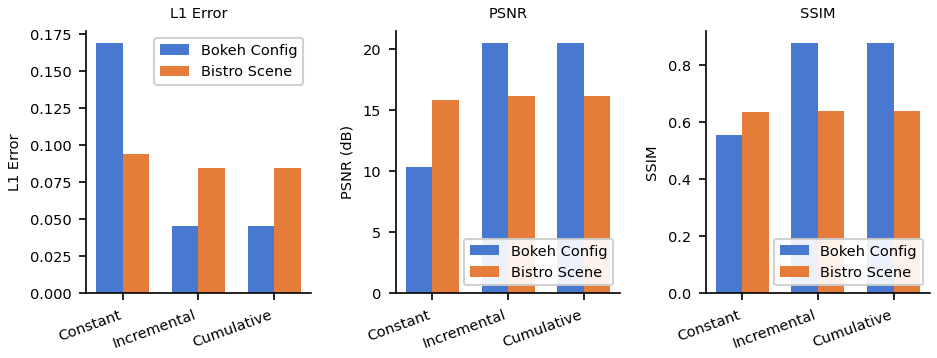

Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314\analysis_output\quality_metrics_comparison.svg


In [108]:
# Quality Metrics Functions
def compute_l1_error(img1, img2):
    """Compute Mean Absolute Error (L1) between two images."""
    return np.mean(np.abs(img1.astype(np.float32) - img2.astype(np.float32)))

def compute_psnr(img1, img2, max_val=1.0):
    """Compute Peak Signal-to-Noise Ratio."""
    img1_f = img1.astype(np.float32)
    img2_f = img2.astype(np.float32)
    mse = np.mean((img1_f - img2_f) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10((max_val ** 2) / mse)

def compute_ssim(img1, img2):
    """Compute Structural Similarity Index."""
    return ssim(img1.astype(np.float32), img2.astype(np.float32), 
                data_range=1.0, channel_axis=2)

def compute_l1_difference_map(img1, img2):
    """Compute L1 difference map for visualization."""
    diff = np.abs(img1.astype(np.float32) - img2.astype(np.float32))
    return np.mean(diff, axis=2)

# Compute metrics for bokeh_config
print("=" * 60)
print("BOKEH CONFIG - Quality Metrics")
print("=" * 60)

bokeh_metrics = {}
gt_bokeh = bokeh_images['ground_truth']

for method in METHODS:
    l1 = compute_l1_error(gt_bokeh, bokeh_images[method])
    psnr = compute_psnr(gt_bokeh, bokeh_images[method])
    ssim_val = compute_ssim(gt_bokeh, bokeh_images[method])
    bokeh_metrics[method] = {'L1': l1, 'PSNR': psnr, 'SSIM': ssim_val}
    print(f"{method.capitalize():15} - L1: {l1:.6f}, PSNR: {psnr:.2f} dB, SSIM: {ssim_val:.4f}")

# Compute metrics for scene
print("\n" + "=" * 60)
print("SCENE - Quality Metrics")
print("=" * 60)

scene_metrics = {}
gt_scene = scene_images['ground_truth']

for method in METHODS:
    l1 = compute_l1_error(gt_scene, scene_images[method])
    psnr = compute_psnr(gt_scene, scene_images[method])
    ssim_val = compute_ssim(gt_scene, scene_images[method])
    scene_metrics[method] = {'L1': l1, 'PSNR': psnr, 'SSIM': ssim_val}
    print(f"{method.capitalize():15} - L1: {l1:.6f}, PSNR: {psnr:.2f} dB, SSIM: {ssim_val:.4f}")

# Compute all difference maps and shared color scale
all_diff_maps = {}
for method in METHODS:
    all_diff_maps[('bokeh', method)] = compute_l1_difference_map(gt_bokeh, bokeh_images[method])
    all_diff_maps[('scene', method)] = compute_l1_difference_map(gt_scene, scene_images[method])

global_vmax = np.percentile(np.concatenate([dm.flatten() for dm in all_diff_maps.values()]), 99)

# L1 Difference Maps - 2x2 per category (GT reference + 3 method diffs)
# Reserve ~0.4" for the colorbar on the right
cbar_frac = 0.06
for cat_key, gt_img, metrics, cat_label in [('bokeh', gt_bokeh, bokeh_metrics, 'Bokeh Config'),
                                              ('scene', gt_scene, scene_metrics, 'Bistro Scene')]:
    fh = fig_height_for_grid(gt_img.shape, 2, 2)
    fig, axes = plt.subplots(2, 2, figsize=(FIG_WIDTH, fh),
                             gridspec_kw={'wspace': 0.04, 'hspace': 0.15})

    # Ground truth reference image
    axes[0, 0].imshow(gt_img)
    axes[0, 0].set_title('Ground Truth (Reference)', fontsize=8)
    axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])

    # Difference maps for each method in remaining positions
    diff_positions = [(0, 1), (1, 0), (1, 1)]
    for (r, c), method, label in zip(diff_positions, METHODS, METHOD_LABELS):
        diff_map = all_diff_maps[(cat_key, method)]
        im = axes[r, c].imshow(diff_map, cmap='hot', vmin=0, vmax=global_vmax)
        axes[r, c].set_title(f'{label}  (L1={metrics[method]["L1"]:.4f})', fontsize=8)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])

    #fig.suptitle(f'{cat_label} - L1 Difference', fontsize=10, y=0.99)
    fig.subplots_adjust(right=1 - cbar_frac - 0.02)
    cbar_ax = fig.add_axes([1 - cbar_frac, 0.08, 0.015, 0.84])
    fig.colorbar(im, cax=cbar_ax, label='L1 Error')
    plt.savefig(OUTPUT_DIR / f"quality_l1_difference_maps_{cat_key}.svg", format='svg', bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR / f'quality_l1_difference_maps_{cat_key}.svg'}")

# Quality Metrics Bar Charts (1x3)
fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, 2.5))

x = np.arange(len(METHOD_LABELS))
width = 0.35

# L1 Error
bokeh_l1 = [bokeh_metrics[m]['L1'] for m in METHODS]
scene_l1 = [scene_metrics[m]['L1'] for m in METHODS]
axes[0].bar(x - width/2, bokeh_l1, width, label='Bokeh Config', color=COLORS['constant'])
axes[0].bar(x + width/2, scene_l1, width, label='Bistro Scene', color=COLORS['incremental'])
axes[0].set_ylabel('L1 Error')
axes[0].set_title('L1 Error')
axes[0].set_xticks(x)
axes[0].set_xticklabels(METHOD_LABELS, rotation=20, ha='right')
axes[0].legend(fontsize=7)

# PSNR
bokeh_psnr = [bokeh_metrics[m]['PSNR'] for m in METHODS]
scene_psnr = [scene_metrics[m]['PSNR'] for m in METHODS]
axes[1].bar(x - width/2, bokeh_psnr, width, label='Bokeh Config', color=COLORS['constant'])
axes[1].bar(x + width/2, scene_psnr, width, label='Bistro Scene', color=COLORS['incremental'])
axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('PSNR')
axes[1].set_xticks(x)
axes[1].set_xticklabels(METHOD_LABELS, rotation=20, ha='right')
axes[1].legend(fontsize=7, loc='lower right')

# SSIM
bokeh_ssim = [bokeh_metrics[m]['SSIM'] for m in METHODS]
scene_ssim = [scene_metrics[m]['SSIM'] for m in METHODS]
axes[2].bar(x - width/2, bokeh_ssim, width, label='Bokeh Config', color=COLORS['constant'])
axes[2].bar(x + width/2, scene_ssim, width, label='Bistro Scene', color=COLORS['incremental'])
axes[2].set_ylabel('SSIM')
axes[2].set_title('SSIM')
axes[2].set_xticks(x)
axes[2].set_xticklabels(METHOD_LABELS, rotation=20, ha='right')
axes[2].legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "quality_metrics_comparison.svg", format='svg', bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'quality_metrics_comparison.svg'}")


## Performance

AVAILABLE TIMING KEYS (GatherDOF related)

--- Bokeh Config (constant) ---
  CS: GatherDOF_BokehConfig_BlurFar
  CS: GatherDOF_BokehConfig_DownscaleTileMap_1_4
  CS: GatherDOF_BokehConfig_DownscaleTileMap_1_8
  CS: GatherDOF_BokehConfig_FloodFillFar
  CS: GatherDOF_BokehConfig_FloodFillNear
  CS: GatherDOF_BokehConfig_NearBlur
  CS: GatherDOF_BokehConfig_NearBorder
  CS: GatherDOF_BokehConfig_NearHalo
  CS: GatherDOF_BokehConfig_Recombine
  CS: GatherDOF_BokehConfig_Setup
  CS: GatherDOF_Pinhole_BlurFar
  CS: GatherDOF_Pinhole_DownscaleTileMap_1_4
  CS: GatherDOF_Pinhole_DownscaleTileMap_1_8
  CS: GatherDOF_Pinhole_FloodFillFar
  CS: GatherDOF_Pinhole_FloodFillNear
  CS: GatherDOF_Pinhole_NearBlur
  CS: GatherDOF_Pinhole_NearBorder
  CS: GatherDOF_Pinhole_NearHalo
  CS: GatherDOF_Pinhole_Recombine
  CS: GatherDOF_Pinhole_Setup
  Const: _GatherDOF_BokehConfig_BlurFarCS_0CB
  Const: _GatherDOF_BokehConfig_FloodFillFarCS_0CB
  Const: _GatherDOF_BokehConfig_FloodFillFarCS_1CB
  Const: _Gat

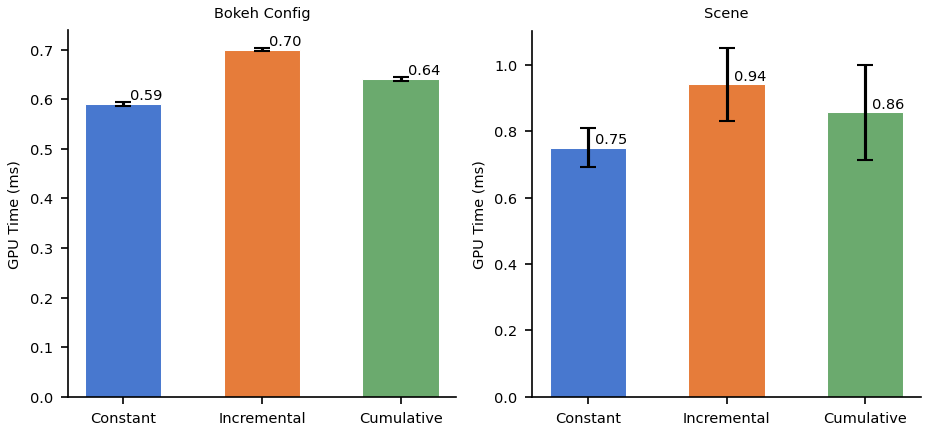

Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314\analysis_output\performance_comparison.svg

--- Bokeh Config Performance ---


,Method,Avg (ms),Std,Min (ms),Max (ms)
0,Constant,0.590203,0.004082,0.578560,0.599040
1,Incremental,0.699607,0.003563,0.690176,0.709632
2,Cumulative,0.640113,0.003660,0.630784,0.649216


Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314\analysis_output\performance_bokeh_config.csv

--- Scene Performance ---


,Method,Avg (ms),Std,Min (ms),Max (ms)
0,Constant,0.750520,0.059004,0.708960,0.876672
1,Incremental,0.940167,0.109993,0.897408,1.356672
2,Cumulative,0.856646,0.142196,0.791104,1.240160


Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314\analysis_output\performance_scene.csv


In [109]:
# Performance Analysis Functions

def extract_timing_by_prefix(profiling_data, prefix):
    """Extract sum of GPU timings for all entries matching the prefix."""
    frame_times = []
    for frame in profiling_data['frames']:
        total_gpu_time = 0.0
        for key, values in frame['timings'].items():
            if key.startswith(prefix):
                total_gpu_time += values[1]
        frame_times.append(total_gpu_time)
    return frame_times

def extract_timing_containing(profiling_data, pattern):
    """Extract sum of GPU timings for all entries containing the pattern."""
    frame_times = []
    for frame in profiling_data['frames']:
        total_gpu_time = 0.0
        for key, values in frame['timings'].items():
            if pattern in key:
                total_gpu_time += values[1]
        frame_times.append(total_gpu_time)
    return frame_times

def extract_timing_exact(profiling_data, timing_name):
    """Extract GPU timing for an exact timing key match."""
    frame_times = []
    for frame in profiling_data['frames']:
        if timing_name in frame['timings']:
            frame_times.append(frame['timings'][timing_name][1])
        else:
            frame_times.append(0.0)
    return frame_times

def get_available_timing_keys(profiling_data, filter_pattern=None):
    """Get all unique timing keys from profiling data, optionally filtered."""
    keys = set()
    for frame in profiling_data['frames']:
        for key in frame['timings'].keys():
            if filter_pattern is None or filter_pattern.lower() in key.lower():
                keys.add(key)
    return sorted(keys)

def compute_timing_stats(frame_times):
    """Compute statistics for timing data."""
    return {
        'avg': np.mean(frame_times),
        'min': np.min(frame_times),
        'max': np.max(frame_times),
        'std': np.std(frame_times)
    }

# Inspect available timing keys
print("=" * 60)
print("AVAILABLE TIMING KEYS (GatherDOF related)")
print("=" * 60)

print("\n--- Bokeh Config (constant) ---")
bokeh_keys = get_available_timing_keys(bokeh_profiling['constant'], 'GatherDOF')
for key in bokeh_keys:
    print(f"  {key}")

print("\n--- Scene (constant) ---")
scene_keys = get_available_timing_keys(scene_profiling['constant'], 'GatherDOF')
for key in scene_keys:
    print(f"  {key}")

BOKEH_GATHER_PATTERN = 'GatherDOF_BokehConfig'
SCENE_GATHER_PATTERN = 'GatherDOF_Pinhole'

def extract_gatherdof_timing(profiling_data, pattern):
    """Extract timing for all GatherDOF operations matching the pattern."""
    all_keys = get_available_timing_keys(profiling_data)
    matching_keys = [k for k in all_keys if pattern in k]
    if not matching_keys:
        print(f"  Warning: No keys found containing '{pattern}'")
        return [0.0] * len(profiling_data['frames']), []
    frame_times = []
    for frame in profiling_data['frames']:
        total_gpu_time = 0.0
        for key in matching_keys:
            if key in frame['timings']:
                total_gpu_time += frame['timings'][key][1]
        frame_times.append(total_gpu_time)
    return frame_times, matching_keys

# Extract bokeh_config timings
print("\n" + "=" * 60)
print("BOKEH CONFIG - GatherDOF_BokehConfig Performance (All Parts)")
print("=" * 60)

bokeh_perf = {}
for method in METHODS:
    cs_times, matched_keys = extract_gatherdof_timing(bokeh_profiling[method], BOKEH_GATHER_PATTERN)
    stats = compute_timing_stats(cs_times)
    bokeh_perf[method] = {'frame_times': cs_times, 'stats': stats, 'keys': matched_keys}
    print(f"{method.capitalize():15} - Avg: {stats['avg']:.3f}ms, Min: {stats['min']:.3f}ms, Max: {stats['max']:.3f}ms")
    for key in matched_keys:
        print(f"    - {key}")

# Extract scene timings
print("\n" + "=" * 60)
print("SCENE - GatherDOF_Pinhole Performance (All Parts)")
print("=" * 60)

scene_perf = {}
for method in METHODS:
    cs_times, matched_keys = extract_gatherdof_timing(scene_profiling[method], SCENE_GATHER_PATTERN)
    stats = compute_timing_stats(cs_times)
    scene_perf[method] = {'frame_times': cs_times, 'stats': stats, 'keys': matched_keys}
    print(f"{method.capitalize():15} - Avg: {stats['avg']:.3f}ms, Min: {stats['min']:.3f}ms, Max: {stats['max']:.3f}ms")
    for key in matched_keys:
        print(f"    - {key}")

# Performance Comparison (1x2)
fig, axes = plt.subplots(1, 2, figsize=(6.3, 3))

x = np.arange(len(METHOD_LABELS))
width = 0.55
bar_colors = [COLORS[m] for m in METHODS]

# Bokeh Config
bokeh_avgs = [bokeh_perf[m]['stats']['avg'] for m in METHODS]
bokeh_errs = [bokeh_perf[m]['stats']['std'] for m in METHODS]
bars1 = axes[0].bar(x, bokeh_avgs, width, yerr=bokeh_errs, capsize=4, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].set_ylabel('GPU Time (ms)')
axes[0].set_title('Bokeh Config')
axes[0].set_xticks(x)
axes[0].set_xticklabels(METHOD_LABELS)
for bar, val in zip(bars1, bokeh_avgs):
    axes[0].text(bar.get_x() + bar.get_width()/2 + 0.05, bar.get_height() + 0.003,
                 f'{val:.2f}', ha='left', va='bottom', fontsize=7)

# Scene
scene_avgs = [scene_perf[m]['stats']['avg'] for m in METHODS]
scene_errs = [scene_perf[m]['stats']['std'] for m in METHODS]
bars2 = axes[1].bar(x, scene_avgs, width, yerr=scene_errs, capsize=4, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].set_ylabel('GPU Time (ms)')
axes[1].set_title('Scene')
axes[1].set_xticks(x)
axes[1].set_xticklabels(METHOD_LABELS)
for bar, val in zip(bars2, scene_avgs):
    axes[1].text(bar.get_x() + bar.get_width()/2 + 0.05, bar.get_height() + 0.003,
                 f'{val:.2f}', ha='left', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "performance_comparison.svg", format='svg', bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'performance_comparison.svg'}")

# CSV tables
bokeh_perf_df = pd.DataFrame({
    'Method': METHOD_LABELS,
    'Avg (ms)': bokeh_avgs,
    'Std': [bokeh_perf[m]['stats']['std'] for m in METHODS],
    'Min (ms)': [bokeh_perf[m]['stats']['min'] for m in METHODS],
    'Max (ms)': [bokeh_perf[m]['stats']['max'] for m in METHODS]
})

scene_perf_df = pd.DataFrame({
    'Method': METHOD_LABELS,
    'Avg (ms)': scene_avgs,
    'Std': [scene_perf[m]['stats']['std'] for m in METHODS],
    'Min (ms)': [scene_perf[m]['stats']['min'] for m in METHODS],
    'Max (ms)': [scene_perf[m]['stats']['max'] for m in METHODS]
})

bokeh_perf_df.to_csv(OUTPUT_DIR / "performance_bokeh_config.csv", index=False)
scene_perf_df.to_csv(OUTPUT_DIR / "performance_scene.csv", index=False)

print(f"\n--- Bokeh Config Performance ---")
display(bokeh_perf_df)
print(f"Saved: {OUTPUT_DIR / 'performance_bokeh_config.csv'}")

print(f"\n--- Scene Performance ---")
display(scene_perf_df)
print(f"Saved: {OUTPUT_DIR / 'performance_scene.csv'}")


## Compare Quality & Performance


SPP COMPARISON - CONSTANT


,SPP,PSNR,SSIM,L1,avg_ms,min_ms,max_ms,std_ms
0,1,9.158072,0.599692,0.193213,0.193782,0.189440,0.197632,0.001792
1,25,9.121649,0.436953,0.201386,0.432148,0.422912,0.440320,0.003337
2,100,9.841245,0.404148,0.189498,1.183171,1.160192,1.216512,0.008835
3,400,10.327014,0.404325,0.176081,4.263639,4.169728,4.344832,0.039984
4,1600,10.365465,0.432831,0.170230,16.877906,16.585729,17.122303,0.127647
5,3600,10.357290,0.462894,0.169214,39.231580,38.537216,39.826432,0.257063
6,6400,10.350595,0.487561,0.169133,69.863363,69.092349,71.618562,0.421864



SPP COMPARISON - INCREMENTAL


,SPP,PSNR,SSIM,L1,avg_ms,min_ms,max_ms,std_ms
0,1,9.402096,0.630232,0.186028,0.199322,0.195584,0.202752,0.001746
1,25,12.202420,0.656292,0.120603,0.542648,0.534528,0.549888,0.003406
2,100,16.012276,0.686088,0.072484,1.646060,1.623040,1.671168,0.008732
3,400,19.200462,0.722875,0.050096,6.152028,5.954560,6.276096,0.055273
4,1600,20.245193,0.773020,0.045187,25.667912,24.762368,26.822657,0.422446
5,3600,20.411640,0.806482,0.045022,59.318180,58.232832,62.167040,0.620197
6,6400,20.480251,0.829414,0.045065,105.522166,104.080383,107.286533,0.649367



SPP COMPARISON - CUMULATIVE


,SPP,PSNR,SSIM,L1,avg_ms,min_ms,max_ms,std_ms
0,1,9.404629,0.629784,0.185939,0.196741,0.191488,0.205824,0.002460
1,25,12.131825,0.655325,0.121843,0.483983,0.477184,0.493568,0.003171
2,100,15.988058,0.684831,0.072655,1.397432,1.369088,1.427456,0.010897
3,400,19.158766,0.722768,0.050298,5.160591,5.020672,5.248000,0.036116
4,1600,20.244839,0.772895,0.045265,20.833301,20.389887,21.527550,0.256406
5,3600,20.399395,0.807264,0.045161,47.994112,47.192062,49.108992,0.358553
6,6400,20.442675,0.828824,0.045274,85.967186,84.270080,87.628800,0.581641



Saved CSVs to C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314\analysis_output


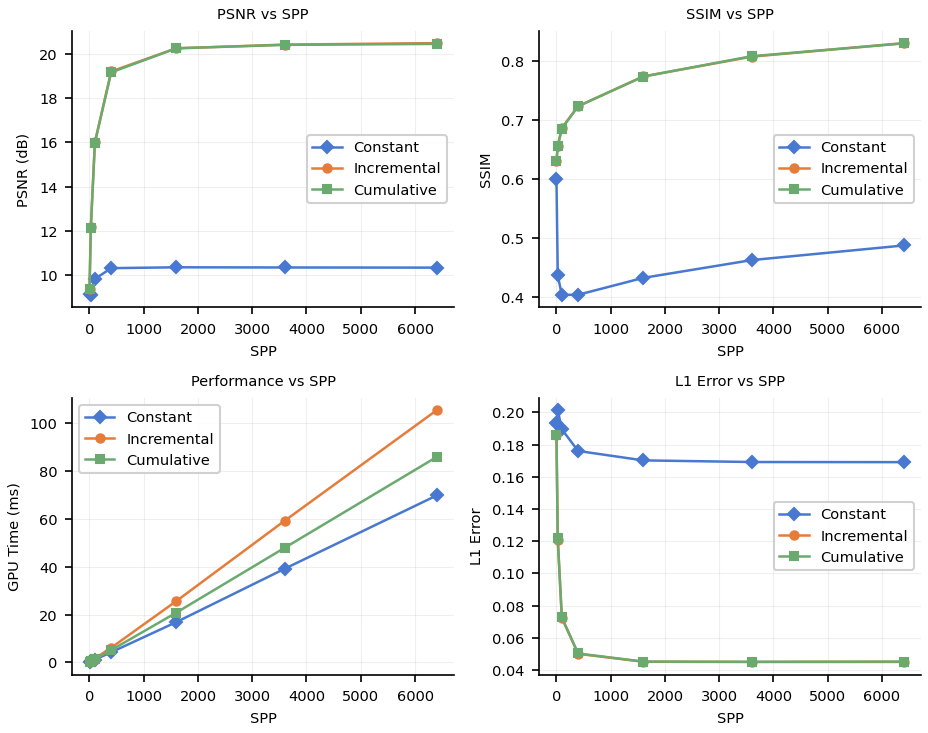

Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314\analysis_output\tap_count_quality_performance.svg


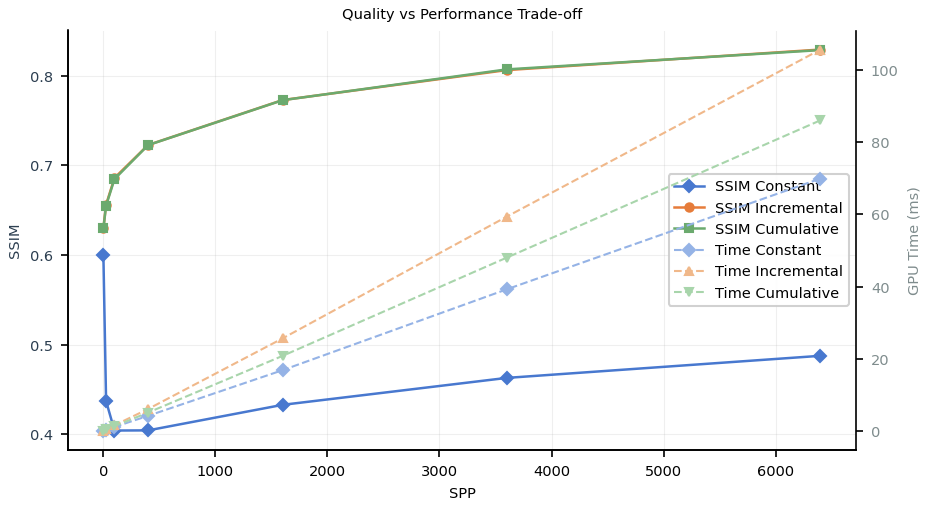

Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314\analysis_output\tap_count_quality_vs_performance.svg

SPP IMAGE GALLERY - CONSTANT


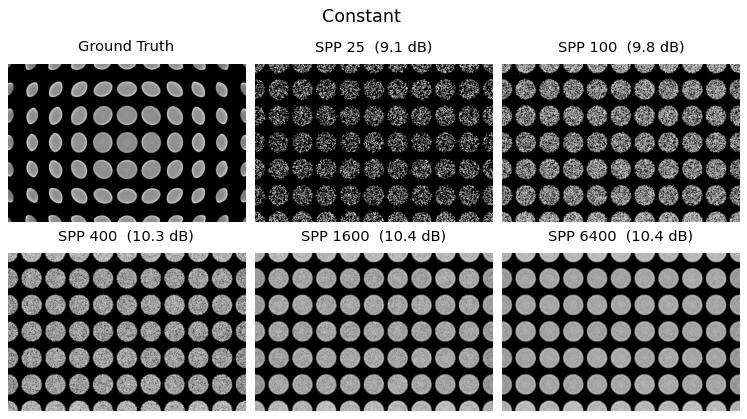

Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314\analysis_output\tap_count_gallery_constant.svg

SPP IMAGE GALLERY - INCREMENTAL


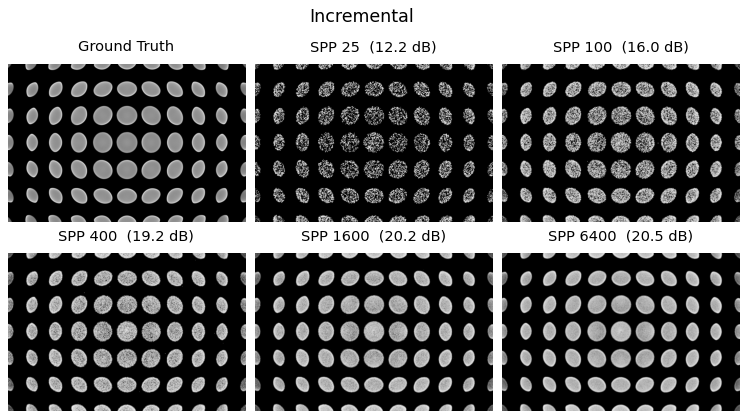

Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314\analysis_output\tap_count_gallery_incremental.svg

SPP IMAGE GALLERY - CUMULATIVE


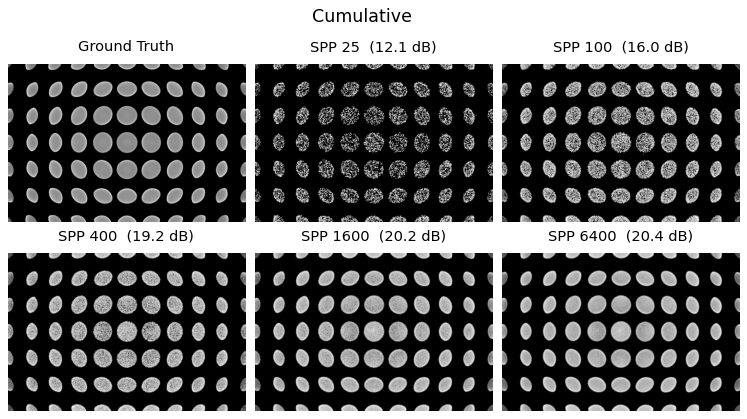

Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314\analysis_output\tap_count_gallery_cumulative.svg

All outputs saved to: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260320_131314\analysis_output


In [ ]:
# Tap Count Comparison - Quality & Performance
gt_bokeh = bokeh_images['ground_truth']

tap_metrics = {'constant': [], 'incremental': [], 'cumulative': []}
tap_performance = {'constant': [], 'incremental': [], 'cumulative': []}
spp_counts = [tc**2 for tc in tap_counts]

for mode in METHODS:
    for tc in tap_counts:
        spp = tc ** 2
        img = tap_count_data[mode][tc]['image']
        psnr = compute_psnr(gt_bokeh, img)
        ssim_val = compute_ssim(gt_bokeh, img)
        l1 = compute_l1_error(gt_bokeh, img)
        tap_metrics[mode].append({'SPP': spp, 'PSNR': psnr, 'SSIM': ssim_val, 'L1': l1})

        profiling = tap_count_data[mode][tc]['profiling']
        cs_times = extract_timing_by_prefix(profiling, 'CS: GatherDOF_BokehConfig')
        stats = compute_timing_stats(cs_times)
        tap_performance[mode].append({
            'SPP': spp, 'avg_ms': stats['avg'], 'min_ms': stats['min'],
            'max_ms': stats['max'], 'std_ms': stats['std']
        })

# Display & save metrics tables
for mode, label in zip(METHODS, METHOD_LABELS):
    print(f"\n{'=' * 60}\nSPP COMPARISON - {label.upper()}\n{'=' * 60}")
    q_df = pd.DataFrame(tap_metrics[mode])
    p_df = pd.DataFrame(tap_performance[mode])
    combined = pd.merge(q_df, p_df, on='SPP')
    display(combined)

const_combined_df = pd.merge(pd.DataFrame(tap_metrics['constant']), pd.DataFrame(tap_performance['constant']), on='SPP')
inc_combined_df = pd.merge(pd.DataFrame(tap_metrics['incremental']), pd.DataFrame(tap_performance['incremental']), on='SPP')
cum_combined_df = pd.merge(pd.DataFrame(tap_metrics['cumulative']), pd.DataFrame(tap_performance['cumulative']), on='SPP')

const_combined_df.to_csv(OUTPUT_DIR / "tap_count_constant.csv", index=False)
inc_combined_df.to_csv(OUTPUT_DIR / "tap_count_incremental.csv", index=False)
cum_combined_df.to_csv(OUTPUT_DIR / "tap_count_cumulative.csv", index=False)
print(f"\nSaved CSVs to {OUTPUT_DIR}")

# Quality & Performance vs SPP (2x2)
fig, axes = plt.subplots(2, 2, figsize=(FIG_WIDTH, 5))

for mode in METHODS:
    c, m = COLORS[mode], MARKERS[mode]
    lbl = mode.capitalize()

    axes[0, 0].plot(spp_counts, [v['PSNR'] for v in tap_metrics[mode]], f'{m}-', label=lbl, color=c, markersize=4, linewidth=1.2)
    axes[0, 1].plot(spp_counts, [v['SSIM'] for v in tap_metrics[mode]], f'{m}-', label=lbl, color=c, markersize=4, linewidth=1.2)
    axes[1, 0].plot(spp_counts, [v['avg_ms'] for v in tap_performance[mode]], f'{m}-', label=lbl, color=c, markersize=4, linewidth=1.2)
    axes[1, 1].plot(spp_counts, [v['L1'] for v in tap_metrics[mode]], f'{m}-', label=lbl, color=c, markersize=4, linewidth=1.2)

axes[0, 0].set(xlabel='SPP', ylabel='PSNR (dB)', title='PSNR vs SPP')
axes[0, 1].set(xlabel='SPP', ylabel='SSIM', title='SSIM vs SPP')
axes[1, 0].set(xlabel='SPP', ylabel='GPU Time (ms)', title='Performance vs SPP')
axes[1, 1].set(xlabel='SPP', ylabel='L1 Error', title='L1 Error vs SPP')

for ax in axes.flat:
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2, linewidth=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tap_count_quality_performance.svg", format='svg', bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'tap_count_quality_performance.svg'}")

# Quality vs Performance Trade-off (dual axis)
fig, ax1 = plt.subplots(figsize=(FIG_WIDTH, 3.5))

ax1.set_xlabel('SPP')
ax1.set_ylabel('SSIM', color='#2c3e50')
lines = []
for mode in METHODS:
    c, m = COLORS[mode], MARKERS[mode]
    l, = ax1.plot(spp_counts, [v['SSIM'] for v in tap_metrics[mode]],
                  f'{m}-', label=f'SSIM {mode.capitalize()}', color=c, markersize=4, linewidth=1.2)
    lines.append(l)
ax1.tick_params(axis='y', labelcolor='#2c3e50')
ax1.grid(True, alpha=0.2, linewidth=0.5)

# Lighter shades for performance lines
perf_colors = {'constant': '#95b3e6', 'incremental': '#f0b88a', 'cumulative': '#a8d5ab'}
perf_markers = {'constant': 'D', 'incremental': '^', 'cumulative': 'v'}
ax2 = ax1.twinx()
ax2.set_ylabel('GPU Time (ms)', color='#7f8c8d')
ax2.spines['right'].set_visible(True)
for mode in METHODS:
    l, = ax2.plot(spp_counts, [v['avg_ms'] for v in tap_performance[mode]],
                  f'{perf_markers[mode]}--', label=f'Time {mode.capitalize()}',
                  color=perf_colors[mode], markersize=4, linewidth=1.0)
    lines.append(l)
ax2.tick_params(axis='y', labelcolor='#7f8c8d')

ax1.legend(lines, [l.get_label() for l in lines], loc='center right')
plt.title('Quality vs Performance Trade-off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tap_count_quality_vs_performance.svg", format='svg', bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'tap_count_quality_vs_performance.svg'}")

# SPP Image Galleries (2x3 with selected SPPs)
selected_tcs = [1, 5, 10, 20, 80]  # SPP: 25, 100, 400, 1600, 6400

for mode, label in zip(METHODS, METHOD_LABELS):
    print(f"\n{'=' * 60}\nSPP IMAGE GALLERY - {label.upper()}\n{'=' * 60}")

    fh = fig_height_for_grid(gt_bokeh.shape, 2, 3)
    fig, axes = plt.subplots(2, 3, figsize=(FIG_WIDTH, fh),
                             gridspec_kw={'wspace': 0.04, 'hspace': 0.12})
    axes_flat = axes.flatten()

    # Ground truth
    axes_flat[0].imshow(gt_bokeh)
    axes_flat[0].set_title('Ground Truth')
    axes_flat[0].axis('off')

    # Selected SPP values
    for i, tc in enumerate(selected_tcs):
        spp = tc ** 2
        tc_idx = tap_counts.index(tc)
        axes_flat[i + 1].imshow(tap_count_data[mode][tc]['image'])
        psnr = tap_metrics[mode][tc_idx]['PSNR']
        axes_flat[i + 1].set_title(f'SPP {spp}  ({psnr:.1f} dB)')
        axes_flat[i + 1].axis('off')

    fig.suptitle(f'{label}', y=0.99)
    plt.savefig(OUTPUT_DIR / f"tap_count_gallery_{mode}.svg", format='svg', bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR / f'tap_count_gallery_{mode}.svg'}")

print(f"\nAll outputs saved to: {OUTPUT_DIR}")
